# 군집화(Clustering)

# 1. 군집화의 기본 개념

비지도 학습 (Unsupervised Learning) 기법으로, 사전에 정해진 정답(레이블) 없이
데이터 객체 간의 유사성만을 바탕으로 그룹(군집)을 형성하는 분석 방법이다.

목적: 데이터의 숨겨진 구조, 패턴, 그룹을 발견하고 고객 세분화 등에 활용

좋은 군집의 조건
1. 군집 내 응집도(Cohesion) 높음: 같은 군집 객체들은 유사해야 함.
2. 군집 간 분리도(Separation) 높음: 다른 군집 객체들은 달라야 함.

유사성/거리 척도
- 연속형 변수: 유클리드 거리 (Euclidean Distance), 맨하탄 거리 (Manhattan Distance), 마할라노비스 거리
- 명목형 변수: 단순일치 계수, 자카드 계수


# 2. 주요 군집화 알고리즘

## (1) K-평균 군집 (K-Means Clustering)

- 원리: 사전에 지정한 K개의 군집 중심(Centroid)을 기준으로 가장 가까운 데이터들을 할당하고,
        할당된 데이터들의 평균으로 중심을 갱신하는 과정을 반복하여 군집을 형성.
- 특징: 알고리즘이 단순하고 빠르다.
- 단점: 군집 수 K를 미리 지정해야 함 (엘보우 기법, 실루엣 계수 사용), 초기 중심값에 민감함.

## (2) 계층적 군집 (Hierarchical Clustering)

- 원리: 군집들을 트리 구조인 덴드로그램(Dendrogram) 형태로 표현하며, K를 미리 지정할 필요가 없다.

- 병합적 (Agglomerative, Bottom-up): 개별 객체에서 시작해 가까운 군집끼리 병합.
    - 연결법: 최단연결법(Single Linkage), 최장연결법(Complete Linkage), 와드연결법(Ward's Linkage)
- 분할적 (Divisive, Top-down): 전체 객체에서 시작해 유사성이 낮은 객체를 분리.

## (3) 밀도 기반 군집 (DBSCAN)

- 원리: 데이터 포인트의 밀도(주어진 반경 내 최소 데이터 수)를 기준으로 군집을 형성.
- 특징: 복잡한 형태의 군집을 찾을 수 있고, K를 미리 지정할 필요가 없으며, 이상치(Noise)를 잘 분리함.
- 매개변수: 반경(Epsilon, $\epsilon$), 최소 데이터 수(MinPts)

## (4) 기타 기법

- 혼합 분포 군집: 데이터가 K개 확률 분포의 가중합이라고 가정, EM 알고리즘으로 모수 추정.
- 자기 조직화 지도 (SOM): 고차원 데이터를 저차원 격자 형태로 투영하여 시각화 (코호넨 맵).

---

# 3. 군집 평가 방법

내부 평가 척도 (Internal Evaluation): 정답 레이블을 모르는 경우
- 실루엣 계수 (Silhouette Coefficient): -1 ~ 1 사이 값으로, 1에 가까울수록 군집이 잘 됨을 의미.
                                        (응집도와 분리도를 모두 고려)
- SSE (Sum of Squared Error): 군집 내 오차제곱합. 작을수록 응집도가 높음.

외부 평가 척도 (External Evaluation): 정답 레이블을 아는 경우
- ARI (Adjusted Rand Index), 정밀도, 재현율, F1-Score 등


In [2]:

# 군집화(Clustering) 실습 데이터셋 컬럼 설명
# 데이터셋은 주로 신용카드 이용 패턴 및 고객의 금융 행동을 나타내는 변수들로 구성되어 있으며,
# 이를 바탕으로 고객을 세분화(Segmentation)하는 군집 분석에 활용될 수 있다.

# 1. **CUST_ID** (문자열)
# - 설명: 고객 고유 식별자
# - 분석 포인트: 클러스터링 시 제외 (ID 컬럼).
#
# 2. **BALANCE** (float)
# - 설명: 고객의 평균 월별 잔액
# - 분석 포인트: 소비 후 남는 평균 금액 (낮을수록 소비 많음, 재정적 여유 지표).
#
# 3. **BALANCE_FREQUENCY** (float, 0~1)
# - 설명: 잔액 갱신 빈도 (1에 가까울수록 잦음)
# - 분석 포인트: 잔액 변동성, 활발한 금융 활동 정도.
#
# 4. **PURCHASES** (float)
# - 설명: 월평균 구매 금액
# - 분석 포인트: 고객의 전체적인 평균 소비 수준.
#
# 5. **ONEOFF_PURCHASES** (float)
# - 설명: 일시불 결제 금액 합계
# - 분석 포인트: 충동적/고액 구매 성향, 일회성 지출 성향.
#
# 6. **INSTALLMENTS_PURCHASES** (float)
# - 설명: 할부 결제 금액 합계
# - 분석 포인트: 장기 지출 성향, 계획적/분할 결제 선호도.
#
# 7. **CASH_ADVANCE** (float)
# - 설명: 현금서비스 사용 금액
# - 분석 포인트: 현금 유동성 부족 여부, 긴급 자금 필요 정도.
#
# 8. **PURCHASES_FREQUENCY** (float, 0~1)
# - 설명: 구매 발생 비율 (1에 가까울수록 빈도가 높음)
# - 분석 포인트: 소비 활동의 전체 빈도.
#
# 9. **ONEOFF_PURCHASES_FREQUENCY** (float)
# - 설명: 일시불 구매 비율
# - 분석 포인트: 단기적 소비/고액 구매 성향 빈도.
#
# 10. **PURCHASES_INSTALLMENTS_FREQUENCY** (float)
# - 설명: 할부 구매 비율
# - 분석 포인트: 할부 이용 빈도, 금융 상품 활용 성향.
#
# 11. **CASH_ADVANCE_FREQUENCY** (float)
# - 설명: 현금서비스 사용 빈도
# - 분석 포인트: 현금 유동성 위험도, 신용 리스크 지표.

# 12. **CASH_ADVANCE_TRX** (int)
# - 설명: 현금서비스 거래 횟수
# - 분석 포인트: 현금서비스 사용 패턴의 횟수 지표.

# 13. **PURCHASES_TRX** (int)
# - 설명: 구매 거래 횟수
# - 분석 포인트: 전체적인 소비 활동의 빈도수.

# 14. **CREDIT_LIMIT** (float)
# - 설명: 신용 한도
# - 분석 포인트: 소득 수준 또는 신용도/리스크 등급 지표.

# 15. **PAYMENTS** (float)
# - 설명: 월별 평균 결제 금액
# - 분석 포인트: 지불 능력 및 상환 규모.

# 16. **MINIMUM_PAYMENTS** (float)
# - 설명: 최소 납부 금액
# - 분석 포인트: 미납 위험성, 신용 관리 성향 (최소 금액만 납부하는 성향 파악).

# 17. **PRC_FULL_PAYMENT** (float, 0~1)
# - 설명: 전체 결제 비율 (1이면 매번 완납하는 고객)
# - 분석 포인트: 신용카드 사용 건전성, 이자 회피 성향.

# 18. **TENURE** (int)
# - 설명: 고객 유지 개월 수
# - 분석 포인트: 거래 기간, 고객 충성도/장기 고객 여부 판단.


In [3]:
# 1. 문제 정의 (Problem Definition)

# 목표: 신용카드 사용자의 소비 패턴을 분석하여 유사한 그룹으로 군집화한다.

# 활용:
# 고객 세그먼테이션(Customer Segmentation)
# 마케팅 전략 수립 (고소득/고소비/저소비 그룹별 맞춤형 서비스 제공)
# 데이터 기반 의사결정:
# 각 클러스터별 평균 소비 금액, 결제 성향 등을 분석해 마케팅 타겟팅 개선

In [4]:
import pandas as pd

df = pd.read_csv('CC GENERAL.csv')

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
# 데이터 전처리
print(df.shape)
df.isnull().sum() 

(8950, 18)


CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
# 결측치가 있는 행 삭제 - MINIMUM_PAYMENTS
df = df.dropna()
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [7]:
# ID 컬럼 제거(분석과 무관)
df = df.drop('CUST_ID', axis=1)
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


In [8]:
df.info() # all -> 수치형 -> 인코딩 생략

<class 'pandas.core.frame.DataFrame'>
Index: 8636 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8636 non-null   float64
 1   BALANCE_FREQUENCY                 8636 non-null   float64
 2   PURCHASES                         8636 non-null   float64
 3   ONEOFF_PURCHASES                  8636 non-null   float64
 4   INSTALLMENTS_PURCHASES            8636 non-null   float64
 5   CASH_ADVANCE                      8636 non-null   float64
 6   PURCHASES_FREQUENCY               8636 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8636 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8636 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8636 non-null   float64
 10  CASH_ADVANCE_TRX                  8636 non-null   int64  
 11  PURCHASES_TRX                     8636 non-null   int64  
 12  CREDIT_LIMI

In [9]:
# 스케일링(정규화만)
# 정규화 (StandardScaler 사용)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.744625,-0.370047,-0.429184,-0.359160,-0.354826,-0.468655,-0.820769,-0.686280,-0.717179,-0.681953,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,-0.537727,0.355181
1,0.764152,0.067679,-0.473208,-0.359160,-0.458839,2.568556,-1.236139,-0.686280,-0.926522,0.557022,0.099258,-0.597054,0.677204,0.796852,0.087689,0.212380,0.355181
2,0.426602,0.505405,-0.116413,0.099909,-0.458839,-0.468655,1.256077,2.646651,-0.926522,-0.681953,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,-0.537727,0.355181
3,-0.373910,0.505405,-0.465825,-0.349660,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,-0.537727,0.355181
4,0.099551,0.505405,0.142062,-0.359160,0.994815,-0.468655,0.425339,-0.686280,0.538882,-0.681953,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,-0.537727,0.355181


In [10]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(scaled_df, test_size=0.3, random_state=42)
train_df.shape, test_df.shape

((6045, 17), (2591, 17))

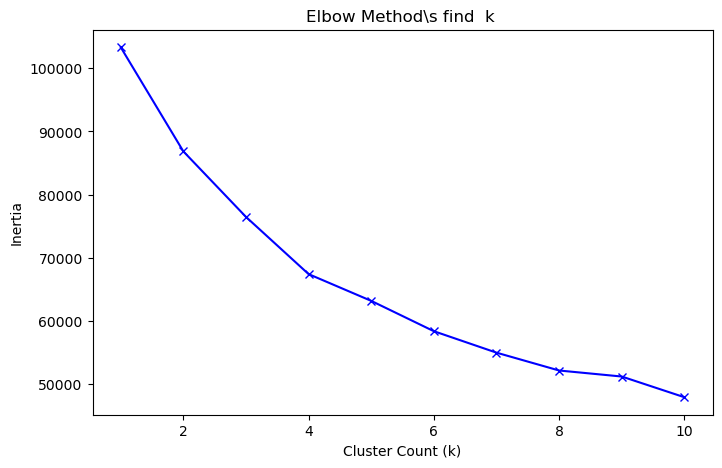

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 적절한 k 찾기 (Elbow Method)
inertia = [] # 각 k 값에 대한 군집 내 거리 제곱합(Inertia)을 저장할 리스트
K = range(1,11) # K 범위(1-10) 클러스터(군집그룹) 개수

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train_df)
    inertia.append(kmeans.inertia_)

# Elbow 그래프 시각화
plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Cluster Count (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method\s find  k ')
plt.show()

In [12]:
# 최적 k 선택 (예: 4)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(train_df)
train_df['cluster'] = kmeans.labels_
train_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
2997,2.985723,0.505405,0.339235,-0.327692,1.402876,3.028419,1.256077,-0.408536,1.585600,0.970012,0.822627,5.042564,2.863577,0.113588,0.454535,-0.537727,0.355181,1
2237,-0.686572,0.067679,-0.286031,-0.359160,-0.016609,-0.468655,1.048393,-0.686280,1.376257,-0.681953,-0.479437,0.316405,-0.634620,-0.402731,-0.309402,-0.537727,0.355181,2
5990,-0.759868,-2.558680,-0.449507,-0.359160,-0.402842,-0.468655,-0.405401,-0.686280,-0.089149,-0.681953,-0.479437,-0.438192,-0.907916,-0.555813,-0.306996,0.137370,0.355181,0
4254,-0.758132,-3.434132,-0.427523,-0.300379,-0.458839,-0.468655,-1.028455,-0.408536,-0.926522,-0.681953,-0.479437,-0.557339,-0.825927,-0.580217,-0.358577,-0.537727,0.355181,0
8183,-0.741101,0.505405,-0.322806,-0.359160,-0.103494,-0.468655,1.256077,-0.686280,1.585600,-0.681953,-0.479437,-0.120467,-0.552631,-0.493809,-0.294213,0.868726,0.355181,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.047498,0.505405,-0.473208,-0.359160,-0.458839,-0.174274,-1.236139,-0.686280,-0.926522,1.795997,0.822627,-0.597054,-0.689279,-0.469433,-0.181087,-0.537727,0.355181,0
5191,-0.198646,0.505405,-0.473208,-0.359160,-0.458839,1.767537,-1.236139,-0.686280,-0.926522,1.795997,0.967300,-0.597054,-0.415982,0.196172,-0.251289,-0.537727,0.355181,1
5390,-0.754265,-0.182450,-0.429378,-0.359160,-0.355284,-0.468655,0.900046,-0.686280,0.867852,-0.681953,-0.479437,-0.358760,-0.962575,-0.583684,-0.320150,1.150015,-3.458970,2
860,2.089937,0.505405,-0.473208,-0.359160,-0.458839,5.191968,-1.236139,-0.686280,-0.926522,1.383007,3.860774,-0.597054,1.770390,2.733127,0.308793,-0.256438,0.355181,1


In [13]:
# 모델 평가
from sklearn.metrics import silhouette_score

score = silhouette_score(train_df.drop('cluster', axis=1), train_df['cluster'])
print('Silhouette Score : ', score)
# Silhouette Score :  0.1979963988501649 # -> 컬럼의 수가 많아도 실루엣계수가 낮게 나올 수 있음


# Silhouette Score는 각 데이터가 자기 클러스터에 잘 속했는지 평가하는 지표
# - 각 데이터 포인트가 **자신의 클러스터에 잘 속했는지**를 수치로 평가
# - 값의 범위: **-1 ~ 1**
# - 값이 1에 가까울수록 → 군집 간 경계가 명확  
# - 값이 0에 가까울수록 → 경계가 모호  
# - 값이 음수일 경우 → 잘못된 클러스터링 가능성 높음

# 점수 해석 기준
# | Silhouette Score | 해석 | 상태 |
# |------------------|------|------|
# | 0.7 ~ 1.0 | 매우 명확하게 구분된 군집 | 매우 우수 |
# | 0.5 ~ 0.7 | 꽤 잘 구분됨 | 양호 |
# | 0.25 ~ 0.5 | 다소 모호함 | 개선 필요 |
# | 0 ~ 0.25 | 거의 섞여 있음 | K값 재조정 필요 |
# | < 0 | 잘못된 군집화 | 비정상적인 모델 |

Silhouett Score :  0.1979963988501649


In [15]:
cluster_summary = df.copy()                            # 원본 데이터 복사
cluster_summary['cluster'] = kmeans.predict(scaled_df) # 예측 결과(클러스터 번호) 추가

# 클러스터별 평균값 계산
summary = cluster_summary.groupby('cluster').mean()
summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,1088.963009,0.820578,275.003178,212.154212,63.126023,617.137753,0.173771,0.087631,0.082654,0.120782,2.243998,2.994520,3290.188761,1019.995650,587.329021,0.083164,11.480689
1,4669.785590,0.968340,506.548947,318.792676,187.846967,4670.652124,0.292276,0.141629,0.188327,0.493463,14.721677,7.806423,7684.259184,3616.829595,2010.502798,0.036355,11.375558
2,913.232629,0.945704,1257.295809,606.886808,650.690231,220.746182,0.886945,0.301141,0.713769,0.043892,0.817545,22.454767,4246.168216,1365.385384,657.416864,0.273849,11.600670
3,3555.748887,0.987038,7765.728125,5152.944750,2614.283375,650.793001,0.945212,0.737534,0.784958,0.070602,2.082500,89.705000,9726.375000,7412.758354,2003.548694,0.293158,11.950000


In [ ]:
# K-Means 군집화 결과 해석

# ------------------------------------------------------------
# 1. 각 군집별 평균값 비교 (summary)
# ------------------------------------------------------------
# cluster | BALANCE | PURCHASES | CASH_ADVANCE | CREDIT_LIMIT | PAYMENTS | PURCHASES_FREQUENCY | PRC_FULL_PAYMENT
# -------------------------------------------------------------------------------------
# 0 | 1088.96 | 275.00 | 617.13 | 3290 | 1019.99 | 0.17 | 0.08
# 1 | 4669.78 | 506.55 | 4670.65 | 7684 | 3616.83 | 0.29 | 0.03
# 2 | 913.23 | 1257.29 | 220.74 | 4246 | 1365.38 | 0.88 | 0.27
# 3 | 3555.74 | 7765.72 | 650.79 | 9726 | 7412.75 | 0.94 | 0.29
# ------------------------------------------------------------
# 2. 군집별 해석
# ------------------------------------------------------------
# cluster 0 → 일반 고객
# - BALANCE(잔액) 낮음
# - PURCHASES(구매액) 낮음
# - PAYMENTS(결제액) 낮음
# - PURCHASES_FREQUENCY 낮음
# → 카드 사용량이 적은 일반적인 사용자
# cluster 1 → 우수 고객
# - BALANCE, CASH_ADVANCE 높음
# - CREDIT_LIMIT, PAYMENTS도 높음
# - PRC_FULL_PAYMENT 낮음
# → 소비는 많지만 현금서비스 의존도가 높은 고객 (신용 중간)
# cluster 2 → 최우수 고객
# - PURCHASES_FREQUENCY 매우 높음 (0.88)
# - CASH_ADVANCE 거의 없음
# - PRC_FULL_PAYMENT 상대적으로 높음 (0.27)
# → 카드 사용 빈도 높고 결제 성실도 높은 고객 (신용 우수)
# cluster 3 → VVIP 고객
# - PURCHASES, PAYMENTS, CREDIT_LIMIT 모두 매우 높음
# - FULL_PAYMENT 비율도 높음
# → 한도 크고 결제 성실한 고소득층 프리미엄 고객
# ------------------------------------------------------------
# 3. 그룹 분할 기준 요약
# ------------------------------------------------------------
# - 소비 수준: PURCHASES, PAYMENTS
# - 현금서비스 의존도: CASH_ADVANCE
# - 결제 성실도: PRC_FULL_PAYMENT
# - 활동성: PURCHASES_FREQUENCY
# → 위 4가지 기준을 종합적으로 고려해 그룹을 해석함

In [14]:
# 활용
# 0 : 일반 고객 
# 1 : 우수 고객
# 2 : 최우수 고객
# 3 : VVIP

# 새로운 고객 데이터 예측 예시
new_data = [[1, 24, 40000, 3000, 150, 30, 1000, 8, 5, 2, 3, 1, 5000, 2, 120, 40, 10]]
new_scaled = scaler.transform(new_data)
pred_cluster = kmeans.predict(new_scaled)
print('신규 고객이 속한 클러스터 : ', pred_cluster[0])

신규 고객이 속한 클러스터 :  3


/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
